<a href="https://colab.research.google.com/github/harishraghavhr7/AgentAI/blob/main/CROPvsWEED_SEGEMENTATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Data from Google Drive

To access files stored in your Google Drive, we need to mount it first. This will allow the Colab environment to access your Drive files as if they were local files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.8 MB/s eta 0:00:00


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/CROP-WEED-SEGMENTATION/dataset"

print(os.listdir(dataset_path))

['labels', 'images', 'data.yaml']


In [ ]:
data_yaml = "/content/drive/MyDrive/CROP-WEED-SEGMENTATION/dataset/data.yaml"

In [ ]:
from ultralytics import YOLO
import yaml # Import yaml to read the file

model = YOLO("yolov8n.pt")

# Print content of data.yaml for debugging
data_yaml_path = "/content/drive/MyDrive/CROP-WEED-SEGMENTATION/dataset/data.yaml"
print(f"Content of {data_yaml_path}:")
try:
    with open(data_yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)
        print(yaml.dump(data_config, indent=2))
except FileNotFoundError:
    print(f"Error: data.yaml not found at {data_yaml_path}")
except Exception as e:
    print(f"Error reading data.yaml: {e}")

model.train(
    data=data_yaml_path, # Use the variable for consistency
    epochs=50,
    imgsz=640,
    batch=16
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Content of /content/drive/MyDrive/CROP-WEED-SEGMENTATION/dataset/data.yaml:
names:
  0: Herb_Paris
  1: Karela
  2: Small_Weed
  3: Grass
  4: Tori
  5: Bhindi
  6: Horseweed
path: dataset
test: /content/drive/MyDrive/CROP-WEED-SEGMENTATION/dataset/images/val
train: /content/drive/MyDrive/CROP-WEED-SEGMENTATION/dataset/images/train
val: /content/drive/MyDrive/CROP-WEED-SEGMENTATION/dataset/images/val

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f9d301f4170>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train/weights/best.pt')

results = model('/content/test.jpg')

for r in results:
    boxes = r.boxes

    for box in boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        print(f"Class: {model.names[cls]}")
        print(f"Confidence: {conf:.2f}")


image 1/1 /content/test.jpg: 384x640 2 Karelas, 11.1ms
Speed: 4.1ms preprocess, 11.1ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
Class: Karela
Confidence: 0.79
Class: Karela
Confidence: 0.61


After running the cell above, you will be prompted to authorize Google Drive access. Once authorized, your Drive content will be available under `/content/drive/My Drive/`. You can then navigate to your desired file path (e.g., `/content/drive/My Drive/path/to/your/data.csv`) and load it using libraries like pandas.

In [ ]:
import shutil

# SOURCE MODEL PATH
source_path = "/content/runs/detect/train/weights/best.pt"

# DESTINATION PATH IN GOOGLE DRIVE
destination_path = "/content/drive/MyDrive/CROP-WEED-SEGMENTATION"
# Copy model
shutil.copy(source_path, destination_path)

print("Model saved to Google Drive!")

Model saved to Google Drive!



0: 640x576 (no detections), 9.8ms
Speed: 2.2ms preprocess, 9.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 576)

0: 640x320 (no detections), 6.4ms
Speed: 1.4ms preprocess, 6.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 320)

0: 640x608 1 Herb_Paris, 1 Karela, 8.0ms
Speed: 3.4ms preprocess, 8.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 608)


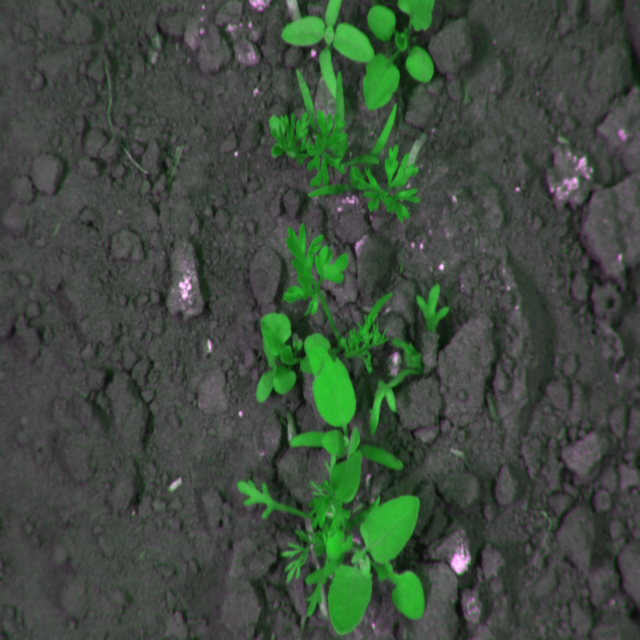

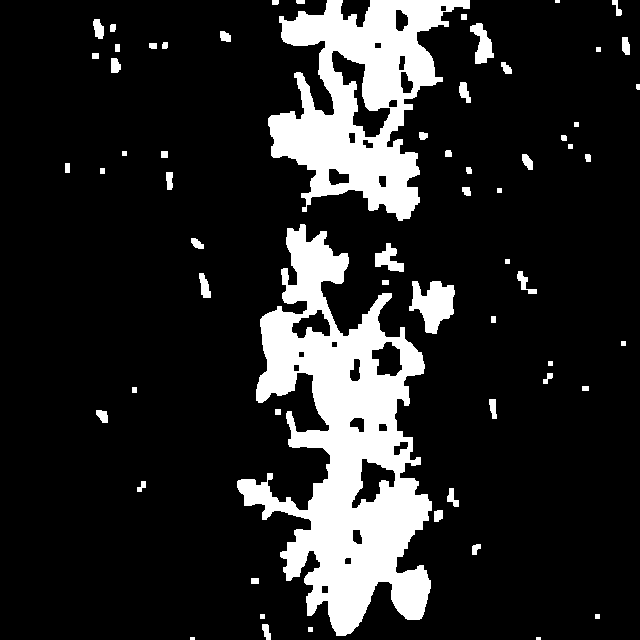

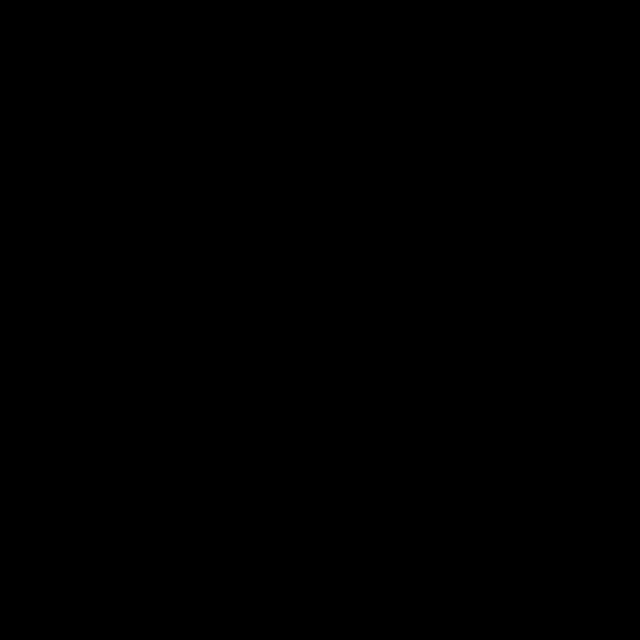

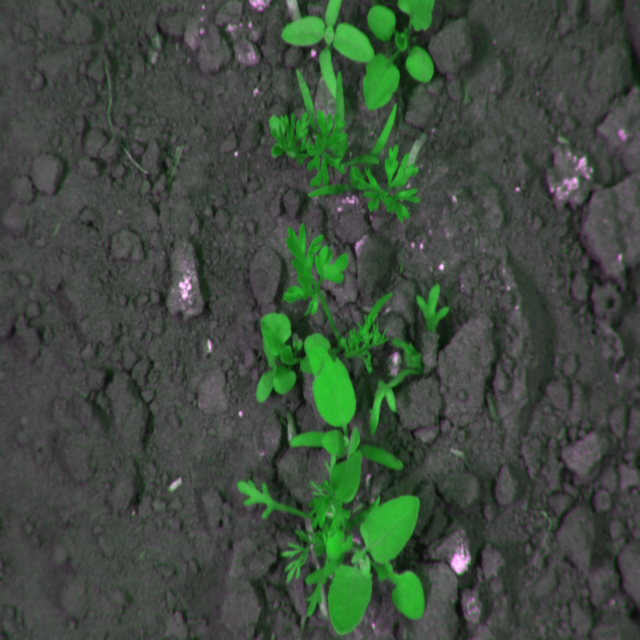

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# =========================
# LOAD YOLO MODEL
# =========================

model = YOLO("/content/drive/MyDrive/CROP-WEED-SEGMENTATION/best.pt")

# =========================
# READ IMAGE
# =========================

image = cv2.imread("test.png")

image = cv2.resize(image, (640, 640))

original = image.copy()

# =========================
# GREEN SEGMENTATION
# =========================

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_green = np.array([35, 40, 40])
upper_green = np.array([90, 255, 255])

plant_mask = cv2.inRange(hsv, lower_green, upper_green)

# remove noise
kernel = np.ones((5,5), np.uint8)

plant_mask = cv2.morphologyEx(
    plant_mask,
    cv2.MORPH_OPEN,
    kernel
)

plant_mask = cv2.morphologyEx(
    plant_mask,
    cv2.MORPH_CLOSE,
    kernel
)

# =========================
# FIND PLANT REGIONS
# =========================

contours, _ = cv2.findContours(
    plant_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# final weed mask
weed_mask = np.zeros(image.shape[:2], dtype=np.uint8)

# =========================
# PROCESS EACH PLANT
# =========================

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area < 500:
        continue

    x, y, w, h = cv2.boundingRect(cnt)

    plant = image[y:y+h, x:x+w]

    # =========================
    # YOLO PREDICTION
    # =========================

    results = model(plant)

    probs = results[0].probs

    if probs is None:
        continue

    class_id = int(probs.top1)

    confidence = float(probs.top1conf)

    label = model.names[class_id]

    # =========================
    # IF WEED
    # =========================

    if label.lower() == "weed":

        cv2.drawContours(
            weed_mask,
            [cnt],
            -1,
            255,
            thickness=cv2.FILLED
        )

        cv2.rectangle(
            image,
            (x, y),
            (x+w, y+h),
            (0, 0, 255),
            2
        )

        cv2.putText(
            image,
            f"Weed {confidence:.2f}",
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,0,255),
            2
        )

# =========================
# SHOW RESULTS
# =========================

cv2_imshow(original)

cv2_imshow(plant_mask)

cv2_imshow(weed_mask)

cv2_imshow(image)


0: 384x640 3 Herb_Pariss, 2 Toris, 1 Bhindi, 64.3ms
Speed: 2.3ms preprocess, 64.3ms inference, 5.1ms postprocess per image at shape (1, 3, 384, 640)
Herb_Paris 0.8586698174476624
Herb_Paris 0.7304427027702332
Tori 0.6879197955131531
Tori 0.5719837546348572
Herb_Paris 0.5506446957588196
Bhindi 0.3346775472164154


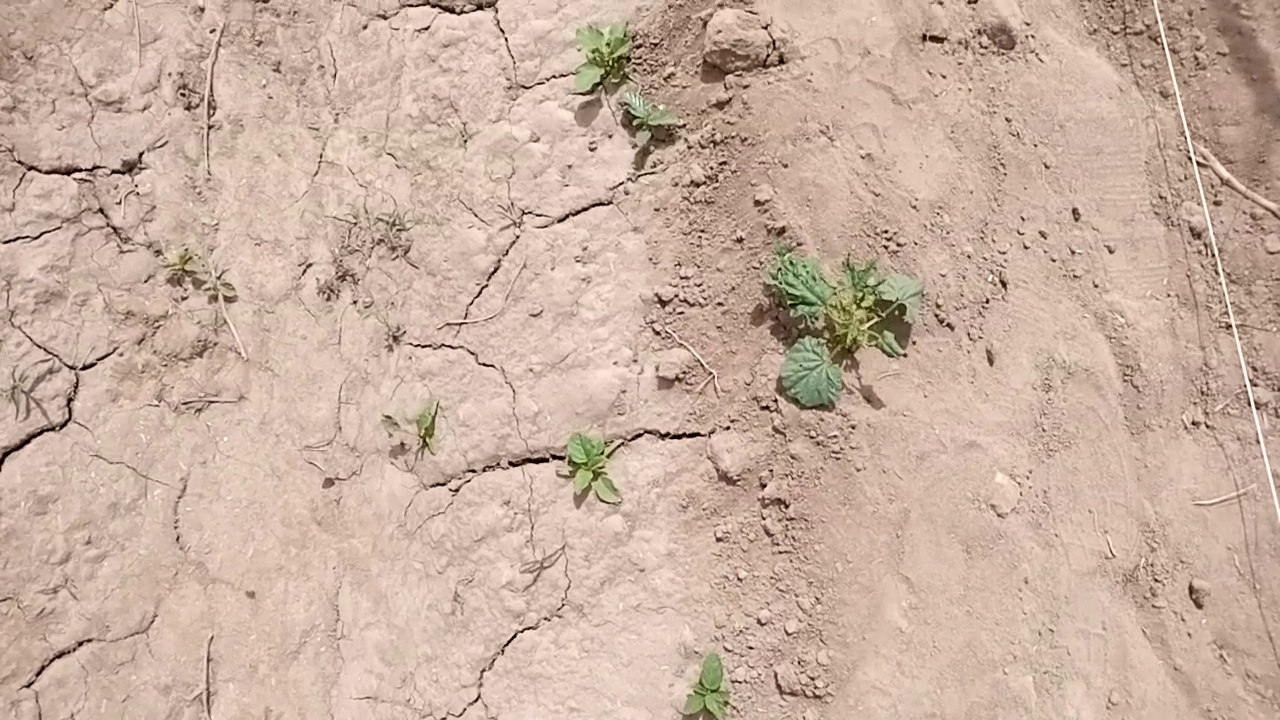

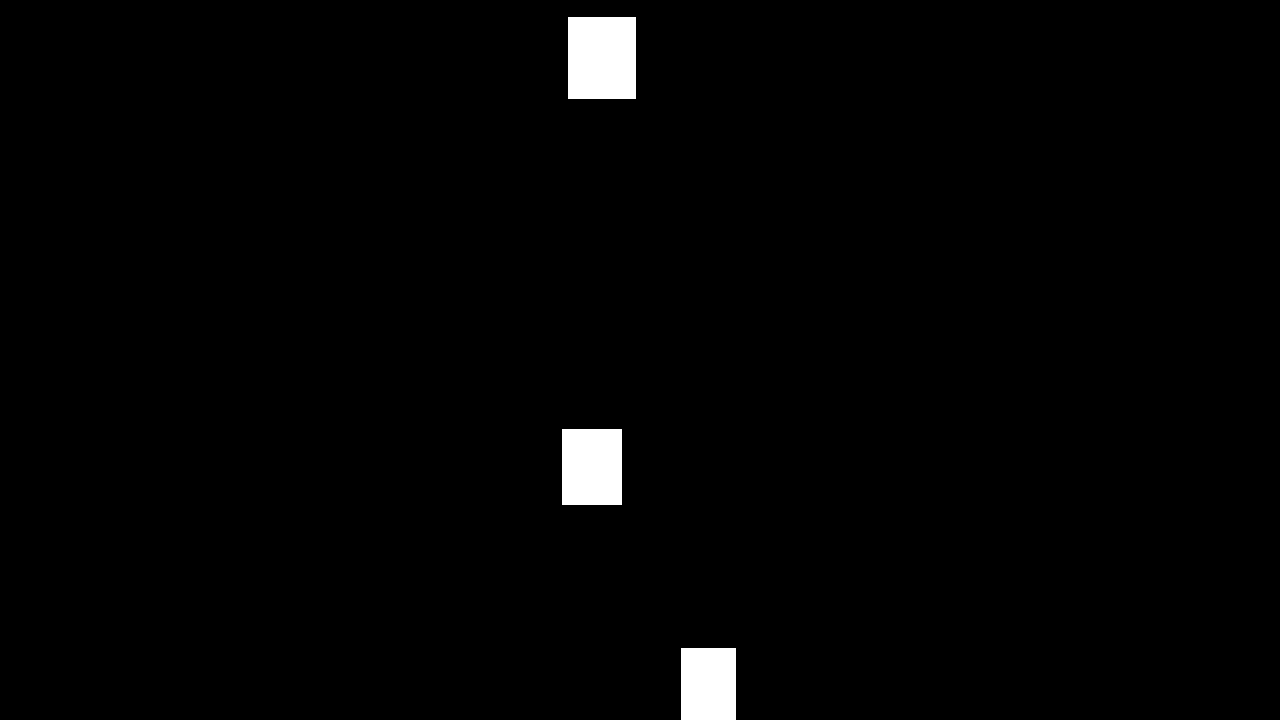

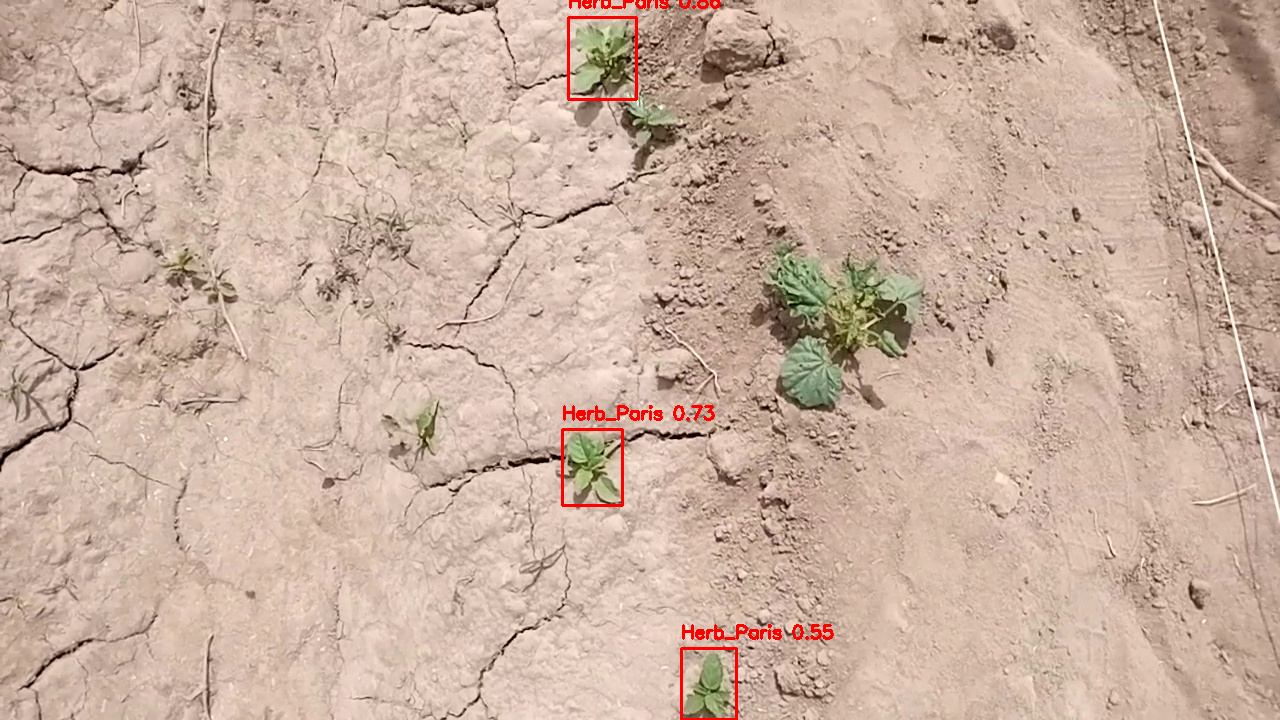

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

# =========================
# LOAD MODEL
# =========================

model = YOLO("/content/drive/MyDrive/CROP-WEED-SEGMENTATION/best.pt")

# =========================
# READ IMAGE
# =========================

image = cv2.imread("test.png")

original = image.copy()

# =========================
# RUN YOLO DETECTION
# =========================

results = model(image)

# segmentation mask
weed_mask = np.zeros(image.shape[:2], dtype=np.uint8)

# =========================
# PROCESS DETECTIONS
# =========================

for result in results:

    boxes = result.boxes

    for box in boxes:

        # coordinates
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # confidence
        conf = float(box.conf[0])

        # class id
        cls = int(box.cls[0])

        # class name
        label = model.names[cls]

        print(label, conf)

        # =========================
        # CREATE SEGMENTATION
        # =========================

        # change according to your weed names
        weed_classes = [
            "Herb_Paris",
            "weed",
            "Karela"
        ]

        if label in weed_classes:

            # fill mask
            weed_mask[y1:y2, x1:x2] = 255

            # draw rectangle
            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (0,0,255),
                2
            )

            # label
            cv2.putText(
                image,
                f"{label} {conf:.2f}",
                (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,0,255),
                2
            )

# =========================
# OPTIONAL MORPHOLOGY
# =========================

kernel = np.ones((5,5), np.uint8)

weed_mask = cv2.morphologyEx(
    weed_mask,
    cv2.MORPH_CLOSE,
    kernel
)

# =========================
# SHOW RESULTS
# =========================

cv2.imshow("Original", original)

cv2.imshow("Weed Mask", weed_mask)

cv2.imshow("Detected Weeds", image)

cv2.waitKey(0)

cv2.destroyAllWindows()